# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

import pydicom
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/requests/__init__.py:109: RequestsDependencyWarning: urllib3 (2.4.0) or chardet (None)/charset_normalizer (2.1.0) doesn't match a supported version!
  warnings.warn(


In [2]:
#seed used for random
seed = 42
torch.manual_seed(seed)

# Loading measurement data

In [ ]:
#read csv
df = pd.read_csv("../data/measurements.csv")

print(df.columns)

#drop unnecessary columns
df.drop(columns = ["Student Name", "Notes", "Unnamed: 23", "Unnamed: 24", "Unnamed: 25", "Unnamed: 26"], inplace = True)

print(df.columns)

print(len(df.columns.values))

In [4]:
#get rid of images with na (only temporary for convenience)
df = df.dropna()

# Load image data (augmentation, datasets, and dataloaders)

In [5]:
#image directory
img_dir = "../data/box_images"

#train test split
train_test_split = 0.8

#batch size
train_batch_size = 128
test_batch_size = 8

#pixels per mm conversion (known)
pix_per_mm = 2400 / 408

#training scale factor
img_scale_factor = 0.1

#image size (pix)
img_width = int(2400 * img_scale_factor)
img_height = int(1920 * img_scale_factor)

In [6]:
#data augmentation settings
## rotation
rot_int = 30
rot_st = 0
rot_en = 360 - rot_int

##down scale
scale_int = 0.1
scale_st = 0.5
scale_en = 0.6 #TODO can change this, 0.6 was chosen so no matter what rotation, no part of image is cut off

In [7]:
# #####FIXME STRICTLY TESTING FIXME#####
# rot_int = 30
# rot_st = 0
# rot_en = 0

# scale_int = 0.1
# scale_st = 1
# scale_en = 1

In [8]:
#class for each data point: image path, flip (if asking for left side of image), rotation, scale, true values for measurements
class DataPoint:
    def __init__(self, img_dir, img_file, img_flip, df, img_width, img_height, aug_rot = 0, aug_scale = 1):
        self.img_path = img_dir + '/' + img_file
        self.img_flip = img_flip
        self.img_width = img_width
        self.img_height = img_height
        self.aug_rot = aug_rot
        self.aug_scale = aug_scale
        self.y = torch.from_numpy(df.loc[df['ID'] == img_file].drop(columns = 'ID').values.astype(np.float32)).reshape(-1)
    
    #apply augmentation, return augmented image and rescaled values for measurements
    def get_image(self):
        ds = pydicom.dcmread(self.img_path)
        img = ds.pixel_array

        img = torch.from_numpy(img).float()
        img = (img - img.min()) / (img.max() - img.min() + 1e-5)
        img = img.unsqueeze(0).unsqueeze(0)

        #flip image if needed
        if self.img_flip:
            img = TF.hflip(img)

        #downscale image
        new_height = int(self.img_height * self.aug_scale)
        new_width = int(self.img_width * self.aug_scale)
        img = F.interpolate(img, size = (new_height, new_width), mode = 'bilinear', align_corners = False)

        #pad back to target size
        pad_height = self.img_height - new_height
        pad_width = self.img_width - new_width
        pad_u = pad_height // 2
        pad_d = pad_height - pad_u
        pad_l = pad_width // 2
        pad_r = pad_width - pad_l
        img = F.pad(img, (pad_l, pad_r, pad_u, pad_d), mode = 'constant', value = 0)

        #rotate image
        img = TF.rotate(img, angle = self.aug_rot, interpolation = TF.InterpolationMode.BILINEAR)

        #get measurements for correct side, rescale all measurements so they are in terms of pixels (except for angle measurement)
        y_aug = self.y.clone()
        if self.img_flip: #left side of image, right set of measurements
            y_aug = y_aug[10:]
        else: #right side of image, left set of measurements
            y_aug = y_aug[:10]
        y_aug[:9] *= self.aug_scale

        return img.squeeze(0), y_aug, torch.tensor(self.aug_scale).float()


In [9]:
class ImageDataset(Dataset):
    def __init__(self, data_points):
        self.data_points = data_points

    def __len__(self):
        return len(self.data_points)

    def __getitem__(self, idx):
        return self.data_points[idx].get_image()

In [10]:
#all images in directory
all_img_in_dir = [i for i in os.listdir(img_dir) if i.lower().endswith("dcm")]

#check all images in df are loaded (else throw error)
for i in df['ID'].values:
    if i not in all_img_in_dir:
        raise SystemError(f'Directory is missing images: {i}')
    
#load only images in the df
all_img = [i for i in all_img_in_dir if i in df['ID'].values]
print(f'Images in use: {len(all_img)}/{len(all_img_in_dir)}')

#split train and test sets
all_idx = torch.randperm(len(all_img))
train_img = [all_img[i] for i in all_idx[:int(train_test_split * len(all_img))]]
test_img = [all_img[i] for i in all_idx[int(train_test_split * len(all_img)):]]

Images in use: 162/3094


In [11]:
#augmented training data in DataPoint class
train_data_points = []
for img_file in train_img:
    for img_flip in range(2):
        for aug_rot in np.arange(rot_st, rot_en + 1e-8, rot_int):
            for aug_scale in np.arange(scale_st, scale_en + 1e-8, scale_int):
                train_data_points.append(DataPoint(img_dir, img_file, img_flip, df, img_width, img_height, aug_rot, aug_scale))
print(f'Augmented training set size: {len(train_data_points)}')

#testing data in DataPoint class (no augmentation transformations applied)
test_data_points = []
for img_file in test_img:
    for img_flip in range(2):
        test_data_points.append(DataPoint(img_dir, img_file, img_flip, df, img_width, img_height, 0, 1))
print(f'Testing set size: {len(test_data_points)}')

Augmented training set size: 6192
Testing set size: 66


In [12]:
#training dataset and data loader
train_set = ImageDataset(train_data_points)
train_loader = DataLoader(train_set, batch_size = train_batch_size, shuffle = True)

#testing dataset and data loader
test_set = ImageDataset(test_data_points)
test_loader = DataLoader(test_set, batch_size = test_batch_size, shuffle = False)

torch.Size([1, 192, 240])
torch.Size([128, 10])
torch.Size([128])


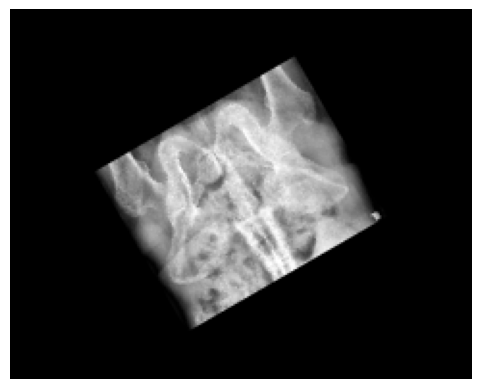

In [13]:
#quick test
for imgs, ys, aug_scales in train_loader:
    print(imgs[0].shape)
    print(ys.shape)
    print(aug_scales.shape)
    plt.imshow(imgs[0].squeeze(), cmap = 'gray')
    plt.axis('off')
    plt.show()
    break


# Model

In [14]:
#number of epochs
epoch_cnt = 20

#learning rate
learning_rate = 1e-3

In [15]:
#model
class CNNModel(nn.Module):
    def __init__(self, img_width, img_height):
        super().__init__()
        self.seq = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size = 3, padding = 1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Flatten(),
            nn.Linear(64 * (img_width // 8) * (img_height // 8), 128),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.seq(x)
        return x

model = CNNModel(img_width, img_height)

In [16]:
#device
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

In [17]:
#loss function
lossfn = nn.MSELoss()

In [18]:
#optimizer
optimizer = optim.Adam(model.parameters(), lr = learning_rate)

In [19]:
for epoch in range(epoch_cnt):
    model.to(device)
    model.train()

    total_loss = 0
    
    for images, yvals, aug_scales in train_loader:
        images = images.to(device)
        yvals = yvals.to(device)

        ypred = model(images)

        loss = lossfn(ypred, yvals)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
    
    # if epoch % 10 and epoch != epoch_cnt - 1: #only print every x epochs
    #     continue

    print(f'Epoch: {epoch}\n')
    print(f'Loss (in sample): {total_loss / len(train_set)}')

    total_loss = 0
    total_percent_err = torch.zeros(10).to(device)
    model.eval()
    for images, yvals, aug_scales in test_loader:
        images = images.to(device)
        yvals = yvals.to(device)

        ypred = model(images)

        loss = lossfn(ypred, yvals)

        total_loss += loss.item()

        total_percent_err += torch.sum(torch.abs(yvals - ypred) / yvals, dim = 0)
    
    print(f'Loss (out sample): {total_loss / len(test_set)}\n')
    print(f'Percent error for each measurement (out sample):')
    for i in total_percent_err:
        print(f'{(i.item() / len(test_set)):.4f}', end = ' ')
    print()

    print('\n===\n')

Epoch: 0

Loss (in sample): 5.475452654737527
Loss (out sample): 138.8378767533736

Percent error for each measurement (out sample):
0.4331 0.5582 0.4338 0.4470 0.4164 0.4559 0.4608 0.4644 0.4706 0.0540 

===

Epoch: 1

Loss (in sample): 1.3285471290272952
Loss (out sample): 113.33976329456677

Percent error for each measurement (out sample):
0.4182 0.4348 0.3803 0.4305 0.4056 0.4164 0.4000 0.4156 0.4120 0.0451 

===

Epoch: 2

Loss (in sample): 0.9611696864283362
Loss (out sample): 84.47201815518466

Percent error for each measurement (out sample):
0.3043 0.2770 0.3249 0.3347 0.3217 0.3328 0.3217 0.3323 0.3408 0.1836 

===

Epoch: 3

Loss (in sample): 0.8578327607738879
Loss (out sample): 83.48767690947561

Percent error for each measurement (out sample):
0.2965 0.3029 0.3304 0.3325 0.3315 0.3481 0.3278 0.3297 0.3388 0.1649 

===

Epoch: 4

Loss (in sample): 0.7902894106330182
Loss (out sample): 87.54840966426966

Percent error for each measurement (out sample):
0.3658 0.3216 0.3480 0

In [23]:
#out of sample testing

model.to(device)
model.eval()

total_loss = 0
total_percent_err = torch.zeros(10).to(device)

for images, yvals, aug_scales in test_loader:
    images = images.to(device)
    yvals = yvals.to(device)

    ypred = model(images)

    loss = lossfn(ypred, yvals)

    total_loss += loss.item()

    total_percent_err += torch.sum(torch.abs(yvals - ypred) / yvals, dim = 0)

    print(ypred[0])
    print(yvals[0])
    print()

print(f'Loss (out sample): {total_loss / len(test_set)}\n')
print(f'Percent error for each measurement (out sample):')
for i in total_percent_err:
    print(f'{(i.item() / len(test_set)):.4f}', end = ' ')
print()

tensor([  4.5201,   3.6825,  24.3459,  33.3622,  26.8094,  51.4859,  23.7006,
         83.7576,  70.9999, 136.4187], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  8.1600,   7.6500,  45.0500,  67.0500,  48.6200, 104.0400,  44.6000,
        171.8600, 138.4200, 136.0100], device='mps:0')

tensor([  4.6202,   3.7804,  25.0201,  34.2755,  27.5270,  52.8737,  24.3509,
         86.0223,  72.9220, 139.3085], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  6.2500,   4.7300,  36.1600,  44.6300,  39.2000,  71.8100,  32.3800,
        114.7200,  99.5100, 132.2700], device='mps:0')

tensor([  4.7142,   3.8367,  25.3770,  34.7876,  27.9490,  53.6834,  24.7122,
         87.3378,  74.0332, 142.1902], device='mps:0',
       grad_fn=<SelectBackward0>)
tensor([  6.6100,   3.2300,  35.0700,  44.9100,  36.1500,  66.3000,  31.8000,
        113.3800,  93.8500, 131.1300], device='mps:0')

tensor([  4.5611,   3.7185,  24.5889,  33.6961,  27.0743,  51.9976,  23.9371,
         84.5907,  